In [1]:
from phasic import Graph, with_ipv # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme, vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

In [2]:
import pandas as pd
import sgkit as sg

# load data for chr20
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")

ds

<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_id             (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                    ...
    variant_filter        (variants, filters) bool 3MB dask.array<chunksize=(1000, 1), meta=np.ndarray>
    variant_id            (variants) object 21MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_id_mask       (variants) bool 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_length        (variants) int8 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_position      (variants) int32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_quality       (variants) float32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    source:                bio2zarr-0.1.7
    vcf_meta_information:  [['fileformat', 'VCFv4.2'], ['fileDate', '06/07/20...
    vcf_zarr_version:      0.4

## Datasæt

Jeg loader et genomisk datasæt med phased varianter for bavianer fra kromosom 20.

Datasættet indeholder:
- Variant positioner
- Genotyper for flere individer
- Sample IDs

Datasættet vil blive opdelt i specifikke populationer (GOG og yellow baboons).

In [3]:
# Hent sample IDs
sample_ids = ds["sample_id"].values

print("Antal samples:", len(sample_ids))
print("Første 10 sample IDs:", sample_ids[:10])

Antal samples: 227
Første 10 sample IDs: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']


## Undersøgelse af samples

Jeg undersøger sample IDs for at forstå hvordan individerne er navngivet.

Disse IDs bruges til at udvælge specifikke populationer.

In [6]:
# Jeg vælger Filoha, Ethiopia, P. Hamadryas og Gog, Ethiopia, P. anubis.
gog_samples = [
    'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724','PD_0725','PD_0726',
    'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733',
    'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740',
    'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'
]

filoha_samples = [
    'PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701', 'PD_0702',
    'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
    'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 'PD_0716',
    'PD_0717', 'PD_0718', 'PD_0719'
]

## Definition af populationer

Jeg definerer to populationer:

- GOG bavianer
- Yellow bavianer

Disse analyseres separat i resten af projektet.

In [7]:
mask_gog = ds["sample_id"].isin(gog_samples).values
mask_filoha = ds["sample_id"].isin(filoha_samples).values

# Lav subsets
ds_gog = ds.isel(samples=mask_gog)
ds_filoha = ds.isel(samples=mask_filoha)

# Tjek resultat
ds_gog, ds_filoha

(<xarray.Dataset> Size: 456MB
 Dimensions:               (variants: 2665269, samples: 25, ploidy: 2,
                            contigs: 1, filters: 1, region_index_values: 2666,
                            region_index_fields: 6, alt_alleles: 1, alleles: 2)
 Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                 region_index_values, region_index_fields,
                                 alt_alleles, alleles
 Data variables: (12/19)
     call_genotype         (variants, samples, ploidy) int8 133MB dask.array<chunksize=(1000, 25, 2), meta=np.ndarray>
     call_genotype_mask    (variants, samples, ploidy) bool 133MB dask.array<chunksize=(1000, 25, 2), meta=np.ndarray>
     call_genotype_phased  (variants, samples) bool 67MB dask.array<chunksize=(1000, 25), meta=np.ndarray>
     contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
     filter_description    (filters) object 8B dask.array<chunksize=(1,)

## Subsetting af data

Jeg udtrækker de relevante individer fra datasættet.

Dette er vigtigt, da alle analyser skal laves på specifikke populationer og ikke hele datasættet samlet.

In [8]:
def compute_derived_counts(ds_sub):
    """
    Beregner antal derived alleler per variant.
    
    Returnerer en DataFrame med:
    - position
    - derived allele count
    - antal kromosomer
    """
    
    # Tæl alleler
    variant_allele_counts = sg.count_variant_alleles(ds_sub)
    
    # Konverter til numpy array (trigger compute)
    ac = variant_allele_counts["variant_allele_count"].values
    
    # Antal haploide kromosomer
    nr_samples = ac.sum(axis=1)
    
    # Lav DataFrame
    df = pd.DataFrame({
        "position": ds_sub["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples": nr_samples,
    })
    
    return df

In [11]:
df_gog = compute_derived_counts(ds_gog)
df_gog.head()

,position,derived_count,nr_samples
0,19,0,50
1,73,0,50
2,126,0,50
3,148,0,50
4,149,0,50


In [12]:
df_filoha = compute_derived_counts(ds_filoha)
df_filoha.head()

,position,derived_count,nr_samples
0,19,0,48
1,73,0,48
2,126,0,48
3,148,0,48
4,149,0,48


### Derived allele counts

For hver variant beregner jeg:

- Antal derived alleler
- Antal kromosomer

Dette bruges til at konstruere Site Frequency Spectrum (SFS).

In [13]:
def compute_sfs(df):
    return df["derived_count"].value_counts().sort_index()

sfs_gog = compute_sfs(df_gog)
sfs_filoha = compute_sfs(df_filoha)

sfs_gog.head()
sfs_filoha.head()

derived_count
0    2161130
1      58964
2      34901
3      26407
4      19938
Name: count, dtype: int64

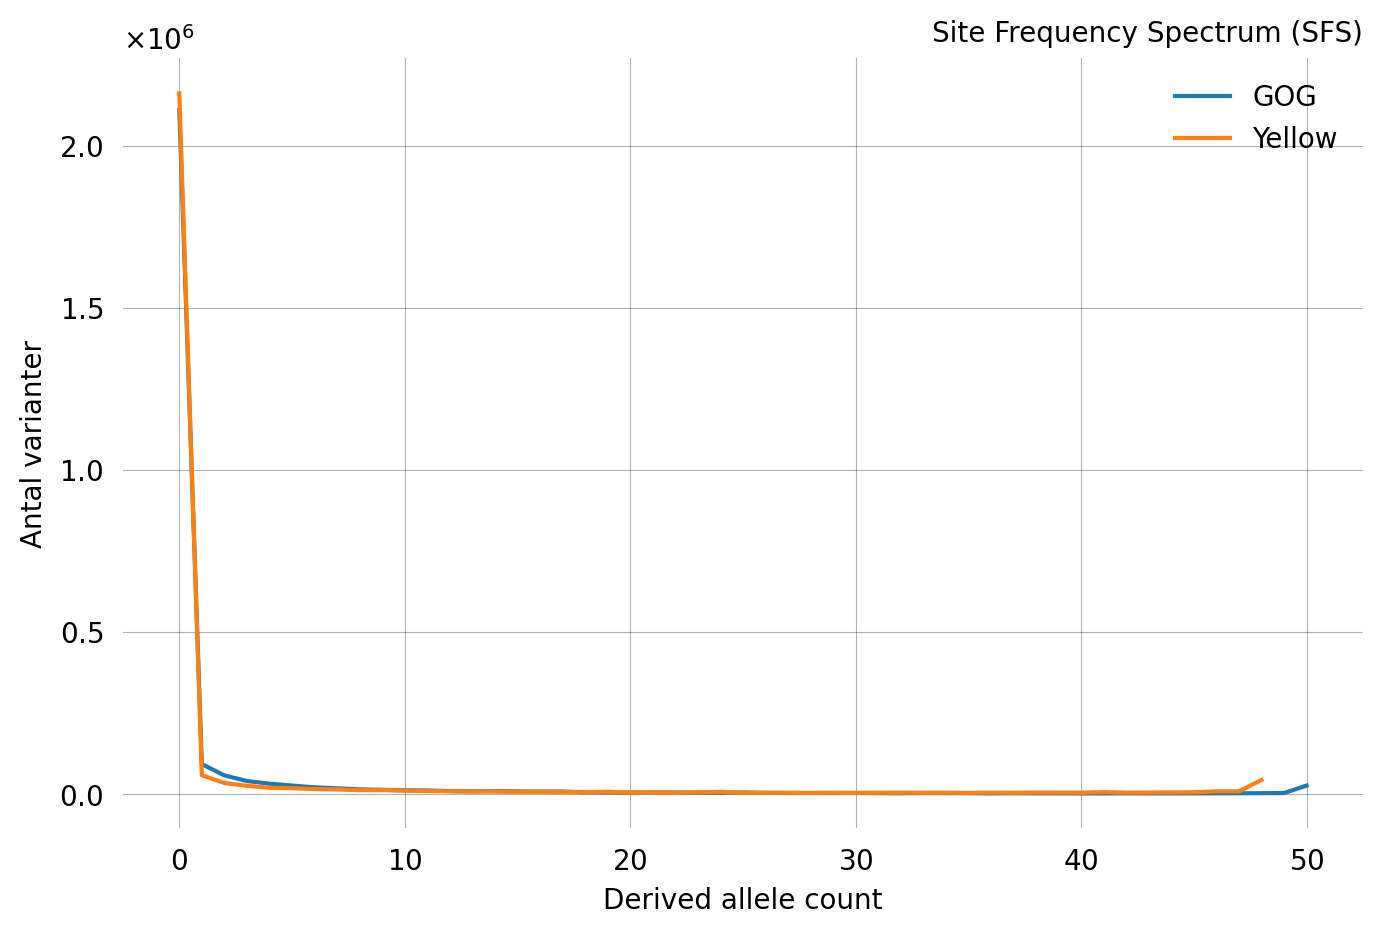

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(sfs_gog.index, sfs_gog.values, label="GOG")
plt.plot(sfs_filoha.index, sfs_filoha.values, label="Yellow")

plt.xlabel("Derived allele count")
plt.ylabel("Antal varianter")
plt.title("Site Frequency Spectrum (SFS)")
plt.legend()

plt.show()

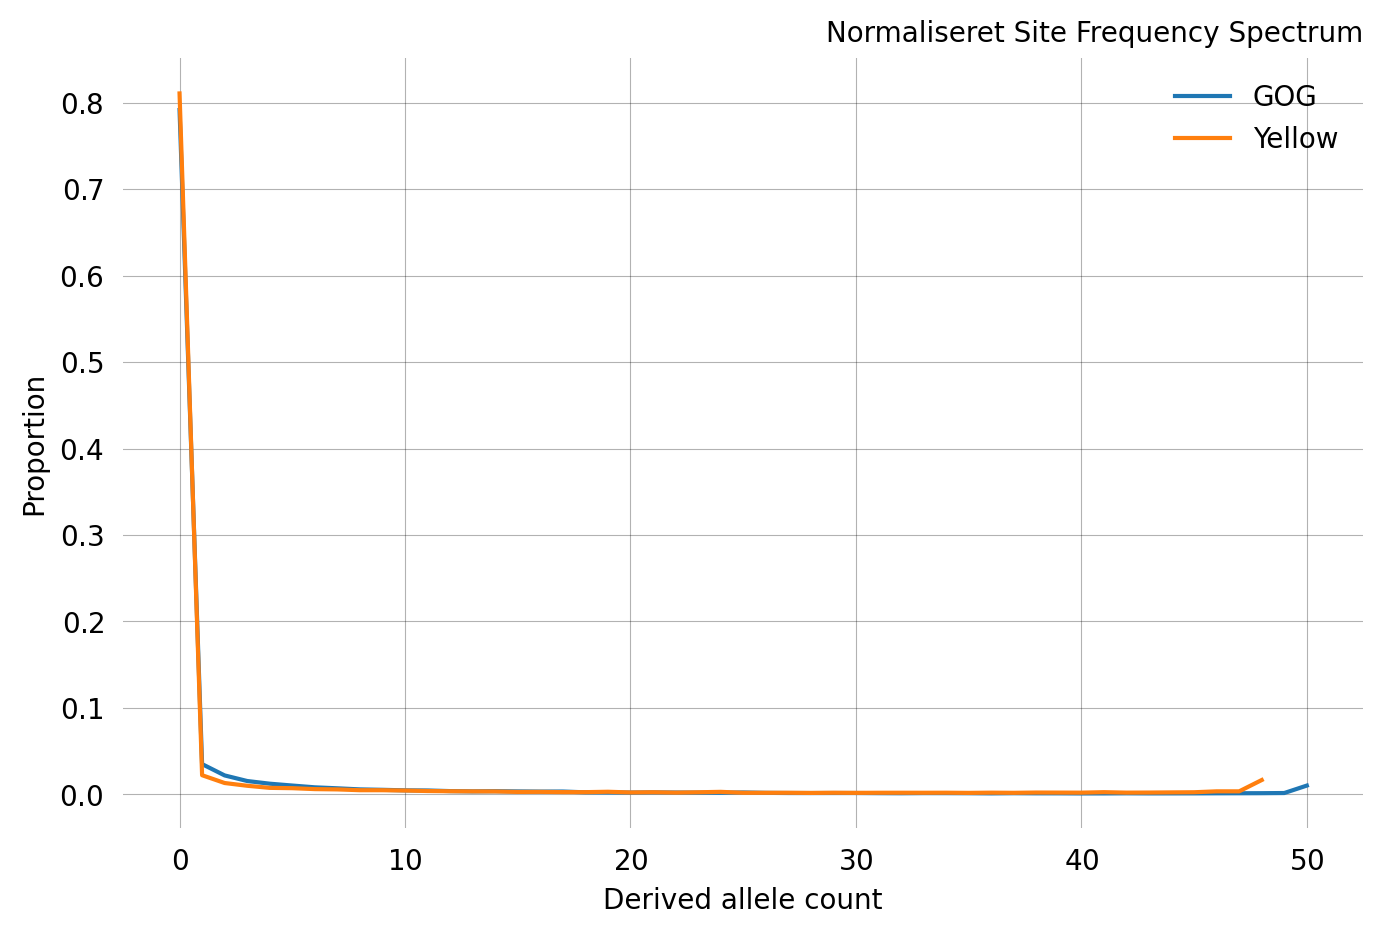

In [15]:
def normalize_sfs(sfs):
    return sfs / sfs.sum()

plt.figure(figsize=(8, 5))

plt.plot(normalize_sfs(sfs_gog), label="GOG")
plt.plot(normalize_sfs(sfs_filoha), label="Yellow")

plt.xlabel("Derived allele count")
plt.ylabel("Proportion")
plt.title("Normaliseret Site Frequency Spectrum")
plt.legend()

plt.show()

Site Frequency Spectrum (SFS) beskriver fordelingen af allelfrekvenser.

Vigtige pointer:

- Singletons (lav frekvens) repræsenterer nye mutationer
- Forskelle mellem populationer kan indikere:
    - forskellig populationsstørrelse
    - historiske bottlenecks
    - admixture

Disse forskelle vil blive analyseret videre i senere notebooks.